# Feature Time Series Analysis

This notebook explores the average temporal profiles of each feature for the two classes (aquaculture vs non-aquaculture) in the training dataset.

We will:
1. Load the training data and drop spatial coordinates (lon, lat).
2. Split the data by label (0 = no-aquaculture, 1 = aquaculture).
3. For each of the 12 features (VH, VV, blue, green, nir, nira, re1, re2, re3, red, swir1, swir2), compute the mean and standard error per month across samples.
4. Plot the monthly means with error bars for both classes in a grid of subplots (12 features).
5. Create box plots to visualize the full distribution of values for each feature, month, and class.

The goal is to visualize seasonal patterns and differences between classes for each remote sensing feature using both parametric (mean ± SEM) and non-parametric (distribution) approaches.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Set plotting style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (15, 10)
plt.rcParams['font.size'] = 12


In [4]:
# Load the training data
train_path = '../data/Train.csv'
if not os.path.exists(train_path):
    # Fallback if run from elsewhere
    train_path = 'data/Train.csv'

train_df = pd.read_csv(train_path)
print(f"Dataset shape: {train_df.shape}")
print(f"Columns: {list(train_df.columns)}")

# Drop lon and lat columns as they are not used for modeling
#df = train_df.drop(columns=['lon', 'lat'])
df = train_df.copy()
print(f"After dropping lon/lat: {df.shape}")

# Show label distribution
label_counts = df['label'].value_counts()
print(f"\nLabel distribution:\n{label_counts}")
print(f"Label percentages:\n{df['label'].value_counts(normalize=True) * 100}")


Dataset shape: (1821, 146)
Columns: ['ID', 'label', 'VH_01', 'VV_01', 'blue_01', 'green_01', 'nir_01', 'nira_01', 're1_01', 're2_01', 're3_01', 'red_01', 'swir1_01', 'swir2_01', 'VH_02', 'VV_02', 'blue_02', 'green_02', 'nir_02', 'nira_02', 're1_02', 're2_02', 're3_02', 'red_02', 'swir1_02', 'swir2_02', 'VH_03', 'VV_03', 'blue_03', 'green_03', 'nir_03', 'nira_03', 're1_03', 're2_03', 're3_03', 'red_03', 'swir1_03', 'swir2_03', 'VH_04', 'VV_04', 'blue_04', 'green_04', 'nir_04', 'nira_04', 're1_04', 're2_04', 're3_04', 'red_04', 'swir1_04', 'swir2_04', 'VH_05', 'VV_05', 'blue_05', 'green_05', 'nir_05', 'nira_05', 're1_05', 're2_05', 're3_05', 'red_05', 'swir1_05', 'swir2_05', 'VH_06', 'VV_06', 'blue_06', 'green_06', 'nir_06', 'nira_06', 're1_06', 're2_06', 're3_06', 'red_06', 'swir1_06', 'swir2_06', 'VH_07', 'VV_07', 'blue_07', 'green_07', 'nir_07', 'nira_07', 're1_07', 're2_07', 're3_07', 'red_07', 'swir1_07', 'swir2_07', 'VH_08', 'VV_08', 'blue_08', 'green_08', 'nir_08', 'nira_08', 're1

In [5]:
# Identify feature columns (exclude ID and label)
id_col = 'ID'
label_col = 'label'
feature_cols = [c for c in df.columns if c not in [id_col, label_col]]
print(f"Number of feature columns: {len(feature_cols)}")
print(f"First few feature columns: {feature_cols[:5]}")

# Verify we have 12 features × 12 months = 144 columns
expected_n = 12 * 12
if len(feature_cols) != expected_n:
    print(f"Warning: Expected {expected_n} feature columns, got {len(feature_cols)}")
else:
    print(f"Confirmed: {len(feature_cols)} feature columns (12 features × 12 months)")


Number of feature columns: 144
First few feature columns: ['VH_01', 'VV_01', 'blue_01', 'green_01', 'nir_01']
Confirmed: 144 feature columns (12 features × 12 months)


In [6]:
# Define the 12 feature base names and month mapping
feature_bases = ['VH', 'VV', 'blue', 'green', 'nir', 'nira', 're1', 're2', 're3', 'red', 'swir1', 'swir2']
month_names = {
    '01': 'Jan', '02': 'Feb', '03': 'Mar', '04': 'Apr',
    '05': 'May', '06': 'Jun', '07': 'Jul', '08': 'Aug',
    '09': 'Sep', '10': 'Oct', '11': 'Nov', '12': 'Dec'
}
months = [f"{i:02d}" for i in range(1, 13)]  # ['01', '02', ..., '12']
month_labels = [month_names[m] for m in months]
print(f"Feature bases: {feature_bases}")
print(f"Month order: {months}")


Feature bases: ['VH', 'VV', 'blue', 'green', 'nir', 'nira', 're1', 're2', 're3', 'red', 'swir1', 'swir2']
Month order: ['01', '02', '03', '04', '05', '06', '07', '08', '09', '10', '11', '12']


In [7]:
# Prepare dictionaries to store mean and standard error for each feature and class
# Structure: results[feature_base][class] = {'mean': array(12), 'sem': array(12)}
results = {}

for fb in feature_bases:
    results[fb] = {0: {'mean': None, 'sem': None}, 1: {'mean': None, 'sem': None}}

# Compute statistics per feature base
for fb in feature_bases:
    # Get the 12 columns for this feature
    cols = [f"{fb}_{m}" for m in months]
    # Verify all columns exist
    missing = [c for c in cols if c not in df.columns]
    if missing:
        raise ValueError(f"Missing columns for feature {fb}: {missing}")
    
    # Extract data for this feature (all samples)
    X_fb = df[cols].values  # shape (n_samples, 12)
    
    # Split by class
    mask_0 = df[label_col] == 0
    mask_1 = df[label_col] == 1
    X_fb_0 = X_fb[mask_0]  # shape (n_0, 12)
    X_fb_1 = X_fb[mask_1]  # shape (n_1, 12)
    
    # Compute mean and standard error for class 0
    if X_fb_0.shape[0] > 0:
        mean_0 = np.mean(X_fb_0, axis=0)
        sem_0 = np.std(X_fb_0, axis=0, ddof=1) / np.sqrt(X_fb_0.shape[0])
    else:
        mean_0 = np.zeros(12)
        sem_0 = np.zeros(12)
    
    # Compute mean and standard error for class 1
    if X_fb_1.shape[0] > 0:
        mean_1 = np.mean(X_fb_1, axis=0)
        sem_1 = np.std(X_fb_1, axis=0, ddof=1) / np.sqrt(X_fb_1.shape[0])
    else:
        mean_1 = np.zeros(12)
        sem_1 = np.zeros(12)
    
    # Store
    results[fb][0]['mean'] = mean_0
    results[fb][0]['sem'] = sem_0
    results[fb][1]['mean'] = mean_1
    results[fb][1]['sem'] = sem_1
    
    # Print summary for this feature
    print(f"{fb}: n_class0={X_fb_0.shape[0]}, n_class1={X_fb_1.shape[0]}")


VH: n_class0=1086, n_class1=735
VV: n_class0=1086, n_class1=735
blue: n_class0=1086, n_class1=735
green: n_class0=1086, n_class1=735
nir: n_class0=1086, n_class1=735
nira: n_class0=1086, n_class1=735
re1: n_class0=1086, n_class1=735
re2: n_class0=1086, n_class1=735
re3: n_class0=1086, n_class1=735
red: n_class0=1086, n_class1=735
swir1: n_class0=1086, n_class1=735
swir2: n_class0=1086, n_class1=735


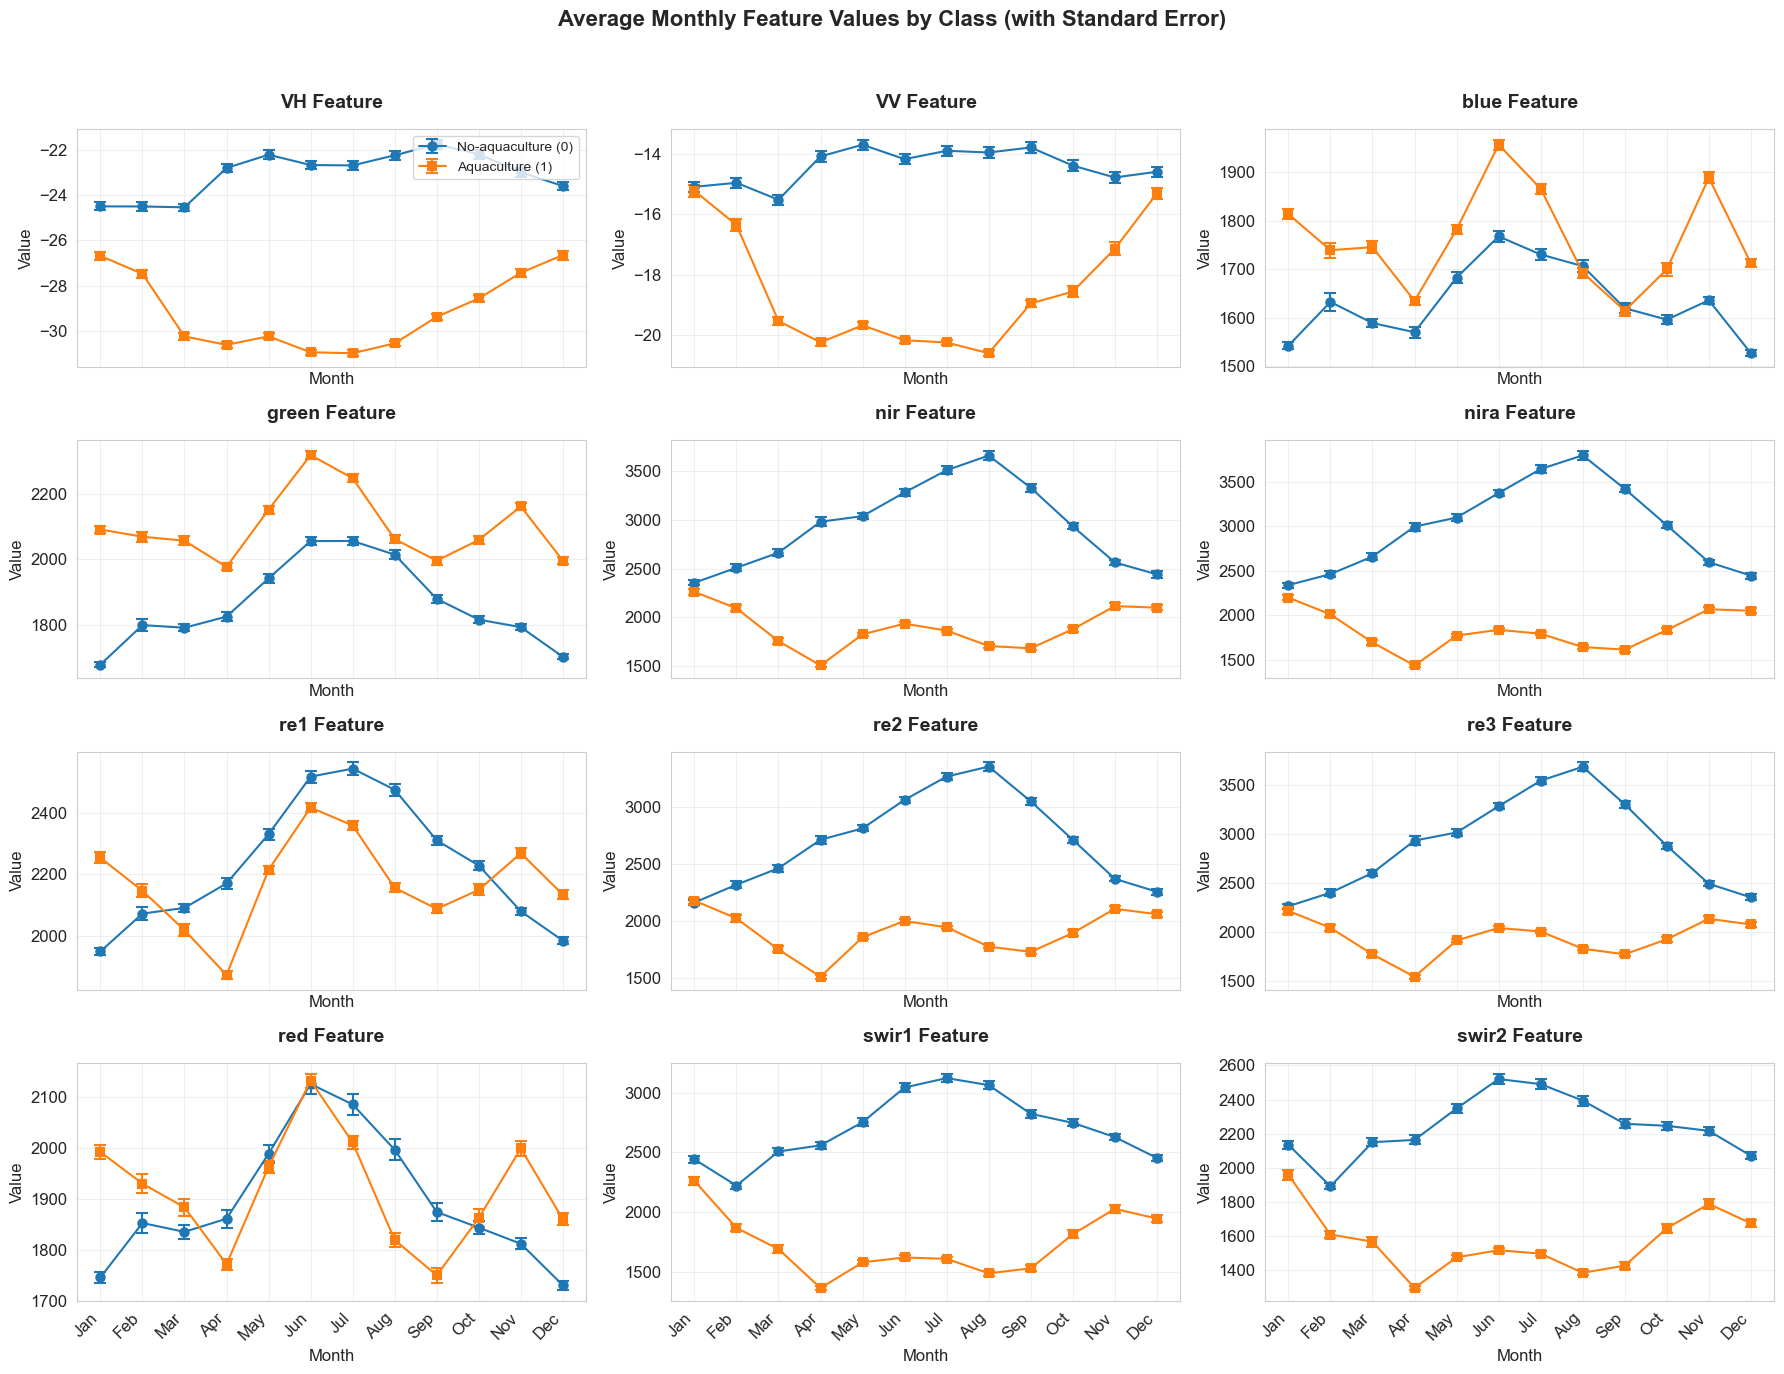

In [8]:
# Create the plot: 12 subplots (4 rows × 3 columns) - Error bar plots (mean ± SEM)
fig, axes = plt.subplots(4, 3, figsize=(18, 14), sharex=True, sharey=False)
axes = axes.flatten()  # flatten to 1D array for easy iteration

# Define colors for classes (colorblind-friendly)
colors = ['#1f77b4', '#ff7f0e']  # blue, orange
class_names = {0: 'No-aquaculture (0)', 1: 'Aquaculture (1)'}

for idx, fb in enumerate(feature_bases):
    ax = axes[idx]
    
    # Get data for this feature
    mean_0 = results[fb][0]['mean']
    sem_0 = results[fb][0]['sem']
    mean_1 = results[fb][1]['mean']
    sem_1 = results[fb][1]['sem']
    
    # x positions (month numbers 1-12)
    x = np.arange(1, 13)
    
    # Plot class 0
    ax.errorbar(x, mean_0, yerr=sem_0, 
                color=colors[0], label=class_names[0],
                marker='o', capsize=4, elinewidth=1.5, markeredgewidth=1.5)
    # Plot class 1
    ax.errorbar(x, mean_1, yerr=sem_1,
                color=colors[1], label=class_names[1],
                marker='s', capsize=4, elinewidth=1.5, markeredgewidth=1.5)
    
    # Customize subplot
    ax.set_title(f'{fb} Feature', fontsize=14, fontweight='bold', pad=15)
    ax.set_xlabel('Month', fontsize=12)
    ax.set_ylabel('Value', fontsize=12)
    ax.set_xticks(x)
    ax.set_xticklabels(month_labels, rotation=45, ha='right')
    ax.grid(True, alpha=0.3)
    
    # Add legend only to the first subplot to avoid redundancy
    if idx == 0:
        ax.legend(loc='upper right', fontsize=10)
    
    # Optional: set y-limits with some padding
    y_min = min(np.min(mean_0 - sem_0), np.min(mean_1 - sem_1))
    y_max = max(np.max(mean_0 + sem_0), np.max(mean_1 + sem_1))
    y_range = y_max - y_min
    if y_range > 0:
        ax.set_ylim(y_min - 0.05 * y_range, y_max + 0.05 * y_range)

# Adjust layout
plt.suptitle('Average Monthly Feature Values by Class (with Standard Error)', 
             fontsize=16, fontweight='bold', y=0.98)
plt.tight_layout(rect=[0, 0, 1, 0.96])  # make room for suptitle
plt.show()


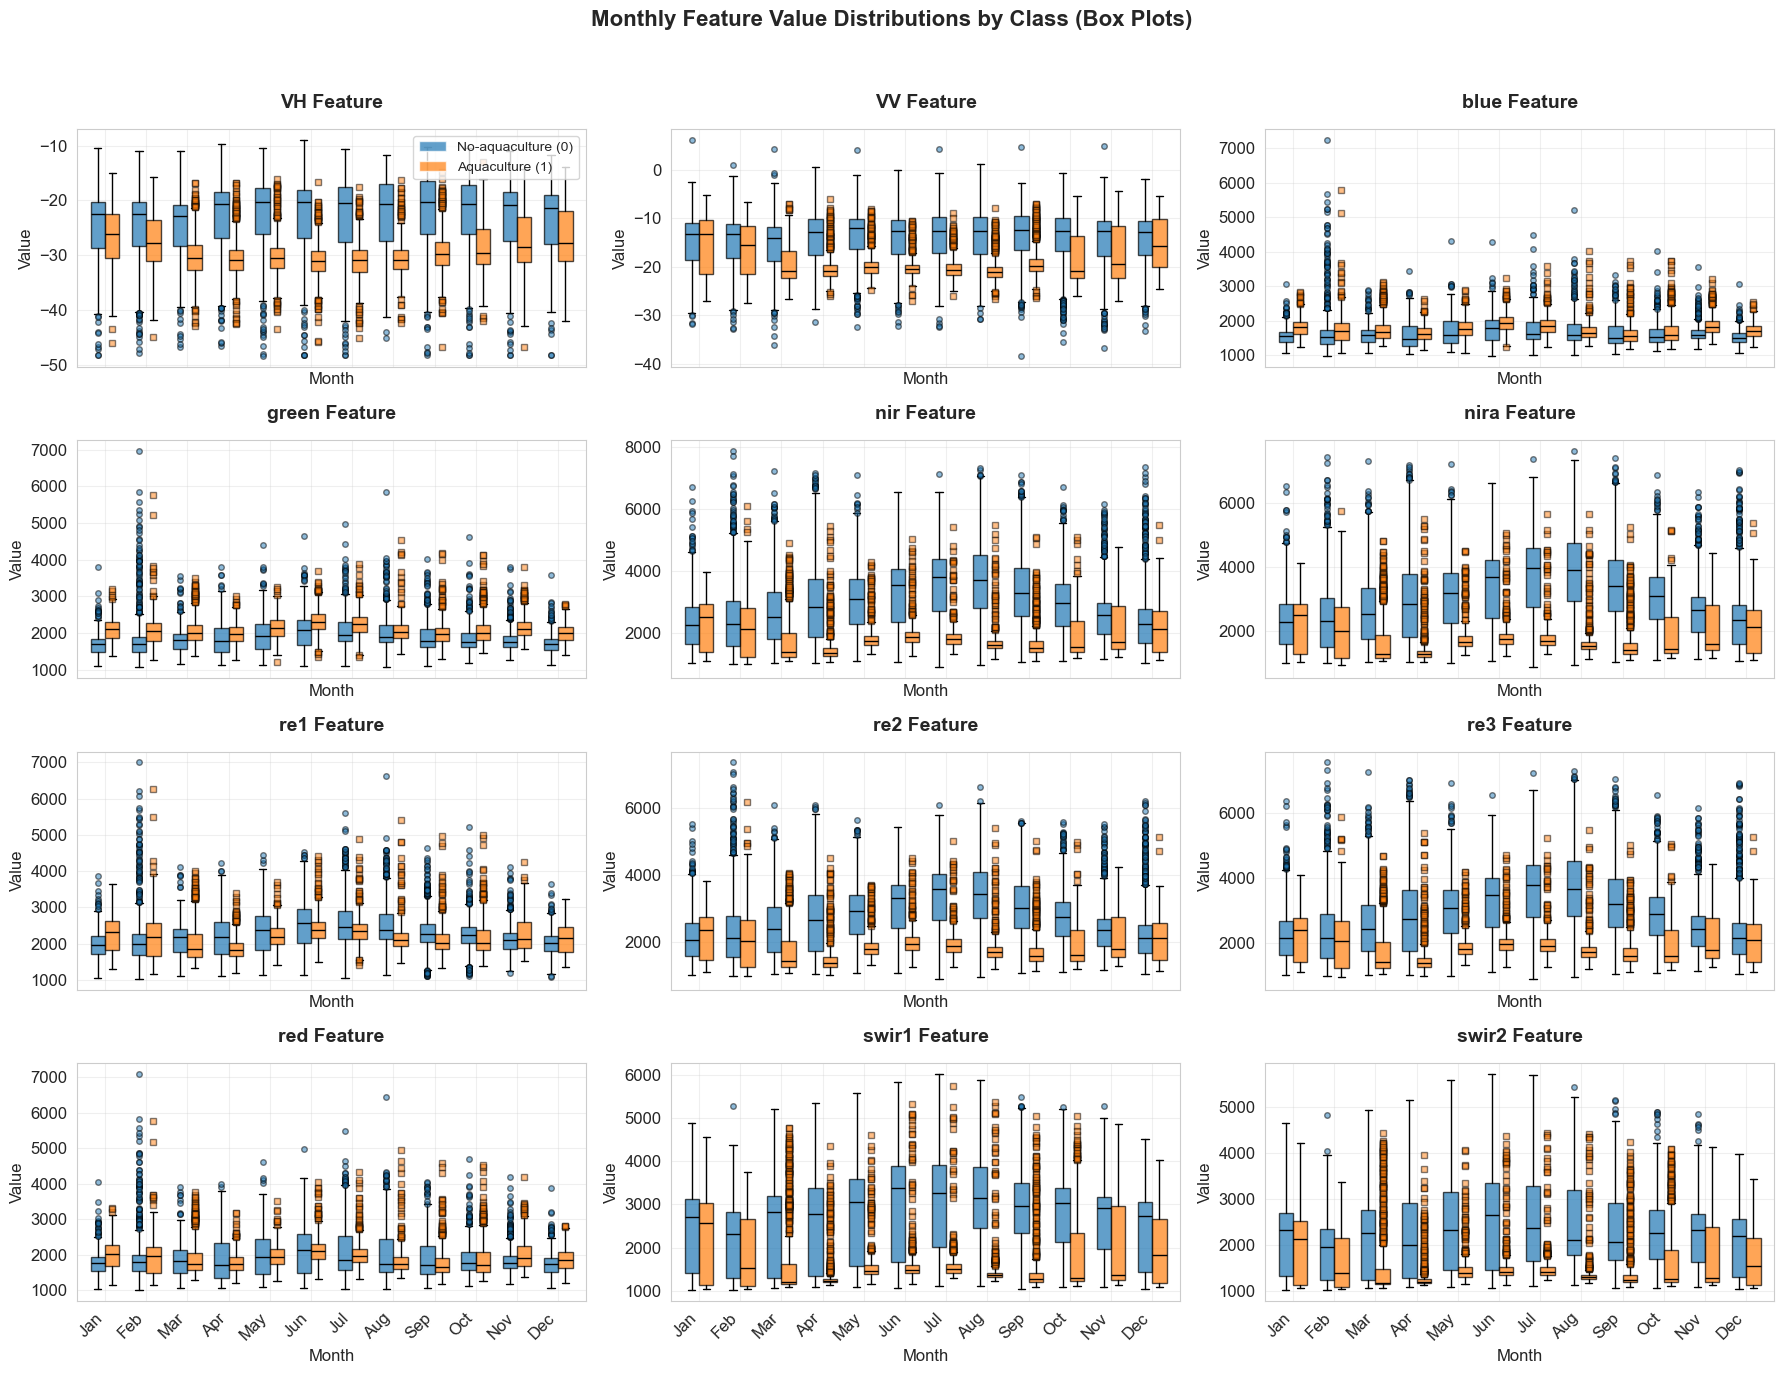

In [9]:
# Create box plots to visualize full distributions
fig2, axes2 = plt.subplots(4, 3, figsize=(18, 14), sharex=True, sharey=False)
axes2 = axes2.flatten()

# Define colors for classes
box_colors = ['#1f77b4', '#ff7f0e']  # blue, orange
class_names = {0: 'No-aquaculture (0)', 1: 'Aquaculture (1)'}

for idx, fb in enumerate(feature_bases):
    ax = axes2[idx]
    
    # Get the 12 columns for this feature
    cols = [f"{fb}_{m}" for m in months]
    
    # Extract data for this feature
    X_fb = df[cols].values
    
    # Split by class
    mask_0 = df[label_col] == 0
    mask_1 = df[label_col] == 1
    X_fb_0 = X_fb[mask_0]
    X_fb_1 = X_fb[mask_1]
    
    # Prepare data for box plots: for each month, we'll have data for each class
    x_positions = np.arange(1, 13)  # 1 to 12 for months
    width = 0.35  # width of each box plot
    
    # Data for each month and class
    data_0_months = [X_fb_0[:, i] for i in range(12)]  # list of 12 arrays (months) for class 0
    data_1_months = [X_fb_1[:, i] for i in range(12)]  # list of 12 arrays (months) for class 1
    
    # Create box plots for each class, positioned side-by-side for each month
    boxes0 = ax.boxplot(data_0_months, positions=x_positions - width/2, widths=width, 
                        patch_artist=True, boxprops=dict(facecolor=box_colors[0], alpha=0.7),
                        medianprops=dict(color='black'), whiskerprops=dict(color='black'),
                        capprops=dict(color='black'), flierprops=dict(marker='o', markerfacecolor=box_colors[0], markersize=4, alpha=0.5))
    
    boxes1 = ax.boxplot(data_1_months, positions=x_positions + width/2, widths=width,
                        patch_artist=True, boxprops=dict(facecolor=box_colors[1], alpha=0.7),
                        medianprops=dict(color='black'), whiskerprops=dict(color='black'),
                        capprops=dict(color='black'), flierprops=dict(marker='s', markerfacecolor=box_colors[1], markersize=4, alpha=0.5))
    
    # Customize subplot
    ax.set_title(f'{fb} Feature', fontsize=14, fontweight='bold', pad=15)
    ax.set_xlabel('Month', fontsize=12)
    ax.set_ylabel('Value', fontsize=12)
    ax.set_xticks(x_positions)
    ax.set_xticklabels(month_labels, rotation=45, ha='right')
    ax.grid(True, alpha=0.3)
    
    # Add legend only to the first subplot
    if idx == 0:
        from matplotlib.patches import Patch
        legend_elements = [
            Patch(facecolor=box_colors[0], alpha=0.7, label=class_names[0]),
            Patch(facecolor=box_colors[1], alpha=0.7, label=class_names[1])
        ]
        ax.legend(handles=legend_elements, loc='upper right', fontsize=10)

# Adjust layout
plt.suptitle('Monthly Feature Value Distributions by Class (Box Plots)', 
             fontsize=16, fontweight='bold', y=0.98)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


---

**Summary**

This notebook has visualized the temporal profiles for each of the 12 remote sensing features using two complementary approaches:

1. **Error Bar Plots (Top)**: Show the mean monthly value for each class with error bars representing the standard error of the mean. This highlights the uncertainty in estimating the average trend.

2. **Box Plots (Bottom)**: Show the full distribution of values for each month and class, including median, quartiles, and potential outliers. This reveals the variability and shape of the data beyond just the mean.

**Observations** (to be filled interactively after running the notebook):
- Look for seasonal patterns (peaks, troughs) in each feature's distribution.
- Compare the central tendency and spread between classes throughout the year.
- Identify which features show the strongest separation between classes in terms of both mean and distribution.
- Note any months where distributions overlap significantly or are well-separated.

**Next Steps**
- Use these insights to inform feature selection or engineering for classification models.
- Consider temporal smoothing or decomposition to extract trend and seasonality components.
- Explore interactions between features (e.g., indices like NDVI) using the monthly profiles.
- Investigate whether specific months or seasons are most discriminative for aquaculture detection.